In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

from attrition_analysis.models_utils import (
    estimators_dict,
    mixed_models_dict_c,
    categorical_models_dict_c,
    prepare_model_data,
    run_cross_validation_mixed,
    run_model_comparison_mixed,
)


df = pd.read_csv("../../data/clean/Employee-Attrition_Clean.csv")

target = "AttritionFlag"

xgboost_estimators_dict = {
    "XGBoost": estimators_dict["XGBoost"],
    "XGBoost Balanced": estimators_dict["XGBoost Balanced"]
}

In [2]:
all_models_dict_c = {**categorical_models_dict_c, **mixed_models_dict_c}

In [3]:
general_comparison_xgb, threshold_comparison_xgb, confusion_results_xgb, trained_models_xgb, interpretation_results_xgb = run_model_comparison_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict=xgboost_estimators_dict,
    target=target
)

general_comparison_xgb.sort_values(by=["F1-score", "AUC"], ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
3,Modelo 2 — Nível Hierárquico,XGBoost Balanced,0.5,0.791,0.416,0.732,0.531,0.804,0,8,22
11,Modelo 6 — Perfil Pessoal,XGBoost Balanced,0.5,0.805,0.432,0.676,0.527,0.786,0,9,24
17,Modelo 2 — Nível Hierárquico e Benefícios,XGBoost Balanced,0.5,0.810,0.436,0.620,0.512,0.821,3,8,25
29,Modelo 8 — Integrado Multidimensional,XGBoost Balanced,0.5,0.823,0.459,0.549,0.500,0.781,7,11,43
9,Modelo 5 — Estabilidade e Benefícios,XGBoost Balanced,0.5,0.773,0.382,0.662,0.485,0.779,0,9,24
5,Modelo 3 — Faixa Salarial,XGBoost Balanced,0.5,0.773,0.380,0.648,0.479,0.773,0,8,21
23,Modelo 5 — Antiguidade Organizacional,XGBoost Balanced,0.5,0.789,0.396,0.592,0.475,0.771,5,6,20
25,Modelo 6 — Perfil Pessoal e Condições de Trabalho,XGBoost Balanced,0.5,0.805,0.418,0.535,0.469,0.771,3,8,24
15,Modelo 1 — Função Profissional Misto,XGBoost Balanced,0.5,0.789,0.392,0.563,0.462,0.766,3,7,26
7,Modelo 4 — Trajetória Organizacional,XGBoost Balanced,0.5,0.764,0.364,0.620,0.458,0.756,0,8,22


In [4]:
best_thresholds_xgb = threshold_comparison_xgb.loc[
    threshold_comparison_xgb.groupby(["Variable_Set", "Model"])["F1-score"].idxmax()
].reset_index(drop=True)

best_thresholds_xgb.sort_values(by="F1-score", ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
6,Modelo 2 — Nível Hierárquico e Benefícios,XGBoost,0.275,0.857,0.556,0.563,0.559,0.829
4,Modelo 2 — Nível Hierárquico,XGBoost,0.250,0.834,0.489,0.634,0.552,0.808
7,Modelo 2 — Nível Hierárquico e Benefícios,XGBoost Balanced,0.650,0.862,0.581,0.507,0.541,0.821
5,Modelo 2 — Nível Hierárquico,XGBoost Balanced,0.500,0.791,0.416,0.732,0.531,0.804
21,Modelo 6 — Perfil Pessoal,XGBoost Balanced,0.500,0.805,0.432,0.676,0.527,0.786
20,Modelo 6 — Perfil Pessoal,XGBoost,0.200,0.812,0.442,0.648,0.526,0.805
29,Modelo 8 — Integrado Multidimensional,XGBoost Balanced,0.525,0.834,0.487,0.549,0.517,0.781
8,Modelo 3 — Faixa Salarial,XGBoost,0.200,0.798,0.418,0.648,0.508,0.779
18,Modelo 5 — Estabilidade e Benefícios,XGBoost,0.225,0.800,0.419,0.620,0.500,0.788
0,Modelo 1 — Função Profissional,XGBoost,0.250,0.819,0.449,0.563,0.500,0.773


In [5]:
top_5_best_xgb = best_thresholds_xgb.sort_values(by="F1-score", ascending=False).head(5).reset_index(drop=True)

top_5_best_xgb

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
0,Modelo 2 — Nível Hierárquico e Benefícios,XGBoost,0.275,0.857,0.556,0.563,0.559,0.829
1,Modelo 2 — Nível Hierárquico,XGBoost,0.250,0.834,0.489,0.634,0.552,0.808
2,Modelo 2 — Nível Hierárquico e Benefícios,XGBoost Balanced,0.650,0.862,0.581,0.507,0.541,0.821
3,Modelo 2 — Nível Hierárquico,XGBoost Balanced,0.500,0.791,0.416,0.732,0.531,0.804
4,Modelo 6 — Perfil Pessoal,XGBoost Balanced,0.500,0.805,0.432,0.676,0.527,0.786


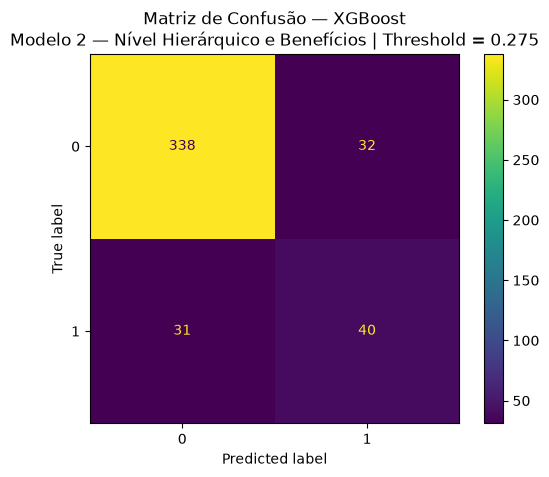

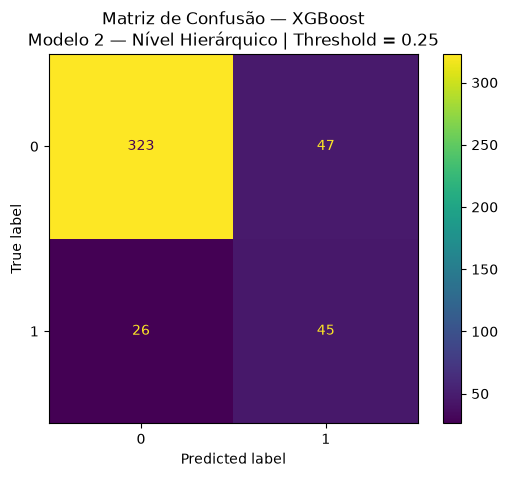

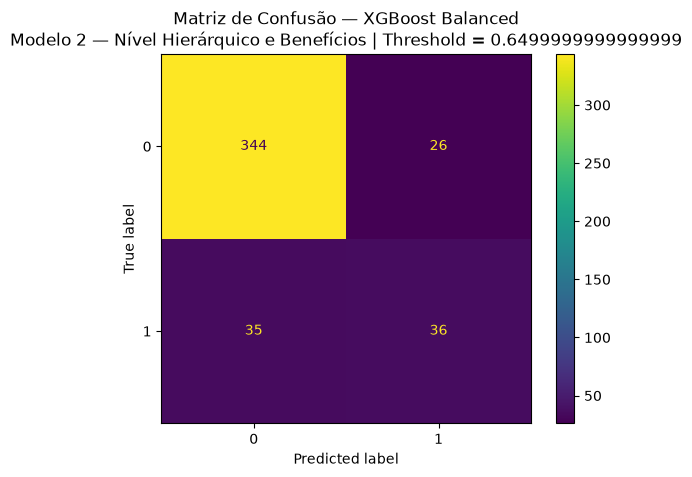

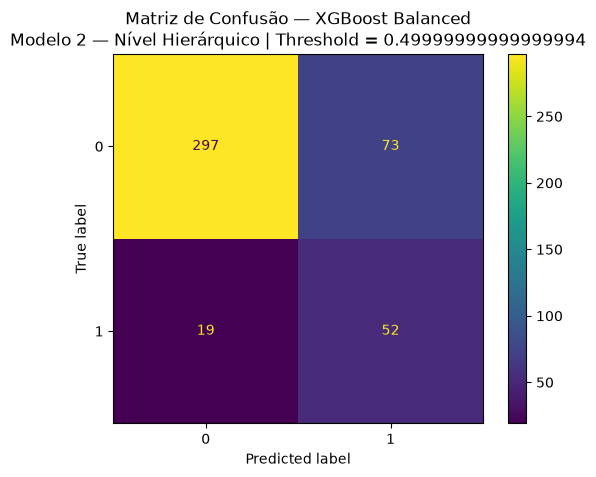

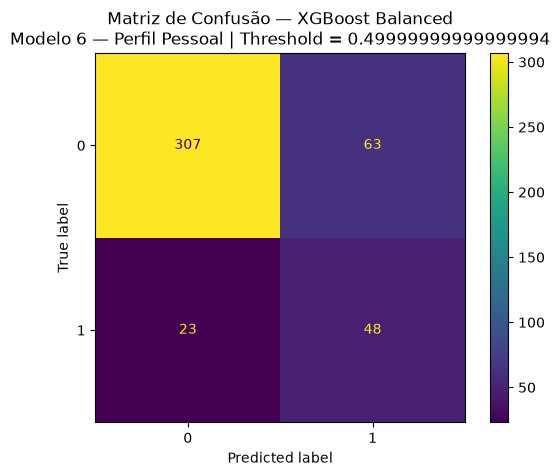

In [6]:
for _, row in top_5_best_xgb.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    best_threshold = row["Threshold"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(xgboost_estimators_dict[model_name]["estimator"])
    balance_method = xgboost_estimators_dict[model_name].get("balance_method", None)
    
    if balance_method == "sample_weight":
        
        sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_train
        )
        
        estimator.fit(X_train, y_train, sample_weight=sample_weight)
        
    else:
        estimator.fit(X_train, y_train)
    
    y_prob = estimator.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusão — {model_name}\n{variable_set_name} | Threshold = {best_threshold}")
    plt.show()

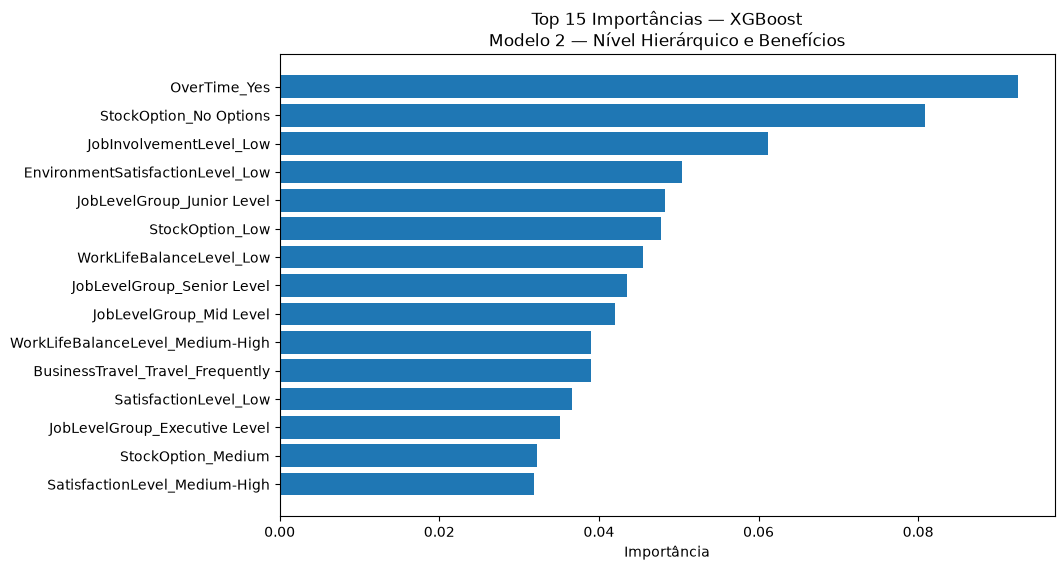

,Feature,Importance
3,OverTime_Yes,0.092476
10,StockOption_No Options,0.080877
13,JobInvolvementLevel_Low,0.061150
16,EnvironmentSatisfactionLevel_Low,0.050457
5,JobLevelGroup_Junior Level,0.048318
8,StockOption_Low,0.047789
22,WorkLifeBalanceLevel_Low,0.045558
7,JobLevelGroup_Senior Level,0.043470
6,JobLevelGroup_Mid Level,0.042023
23,WorkLifeBalanceLevel_Medium-High,0.039020


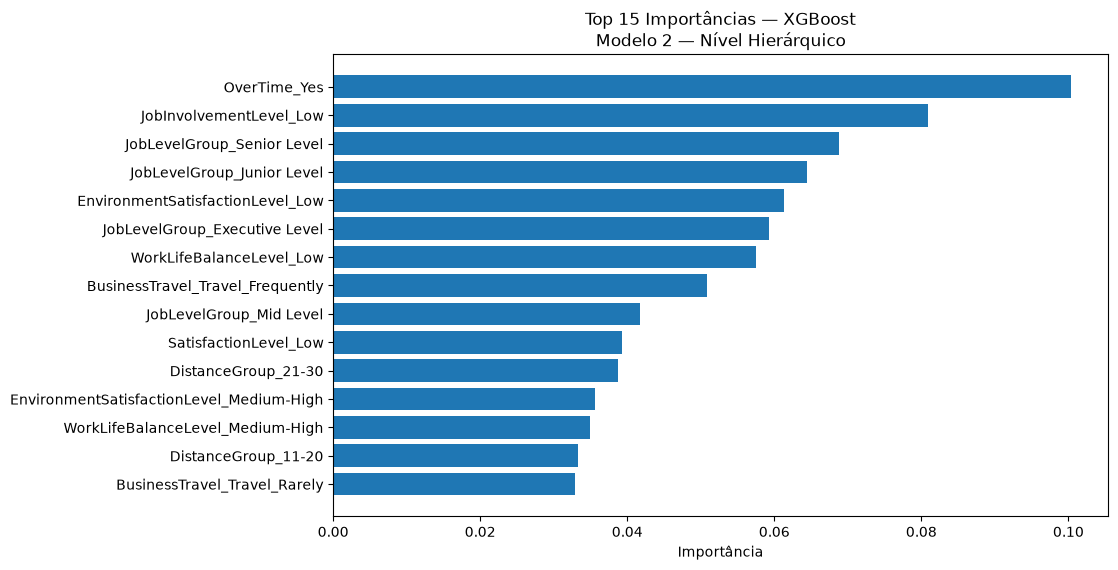

,Feature,Importance
0,OverTime_Yes,0.100386
7,JobInvolvementLevel_Low,0.080867
4,JobLevelGroup_Senior Level,0.068766
2,JobLevelGroup_Junior Level,0.064418
10,EnvironmentSatisfactionLevel_Low,0.061289
1,JobLevelGroup_Executive Level,0.059321
16,WorkLifeBalanceLevel_Low,0.057566
5,BusinessTravel_Travel_Frequently,0.050791
3,JobLevelGroup_Mid Level,0.041754
13,SatisfactionLevel_Low,0.039333


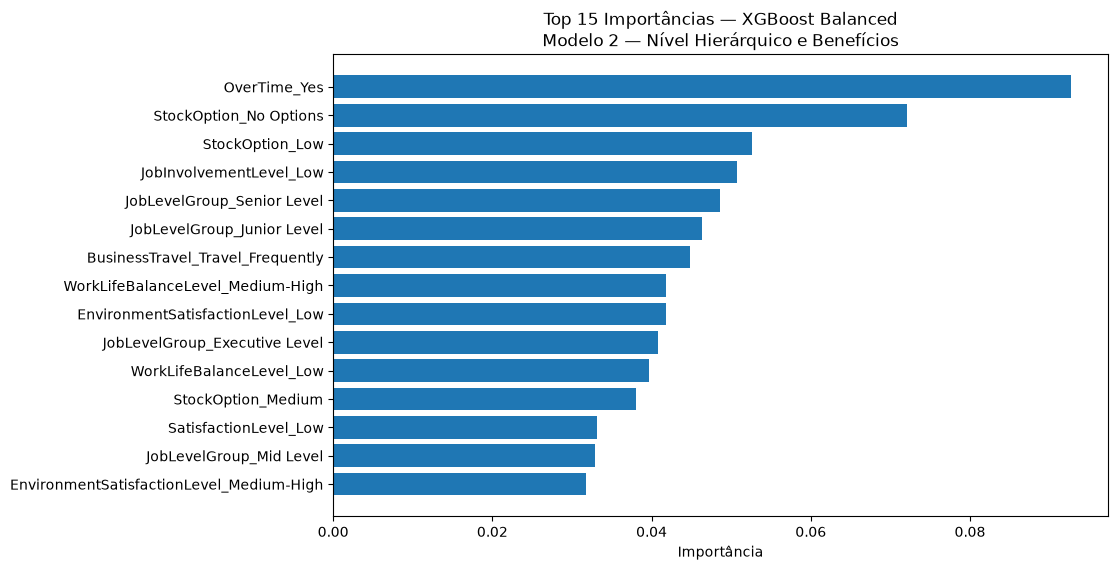

,Feature,Importance
3,OverTime_Yes,0.092719
10,StockOption_No Options,0.072078
8,StockOption_Low,0.052617
13,JobInvolvementLevel_Low,0.050726
7,JobLevelGroup_Senior Level,0.048642
5,JobLevelGroup_Junior Level,0.046394
11,BusinessTravel_Travel_Frequently,0.044856
23,WorkLifeBalanceLevel_Medium-High,0.041859
16,EnvironmentSatisfactionLevel_Low,0.041770
4,JobLevelGroup_Executive Level,0.040752


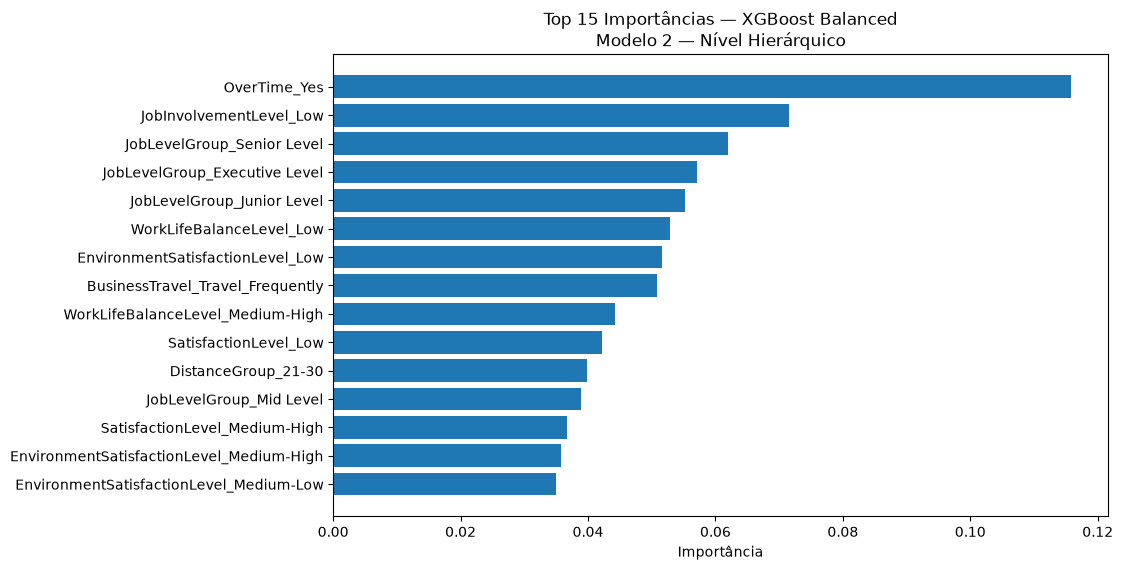

,Feature,Importance
0,OverTime_Yes,0.115847
7,JobInvolvementLevel_Low,0.071483
4,JobLevelGroup_Senior Level,0.062022
1,JobLevelGroup_Executive Level,0.057105
2,JobLevelGroup_Junior Level,0.055191
16,WorkLifeBalanceLevel_Low,0.052906
10,EnvironmentSatisfactionLevel_Low,0.051555
5,BusinessTravel_Travel_Frequently,0.050761
17,WorkLifeBalanceLevel_Medium-High,0.044220
13,SatisfactionLevel_Low,0.042155


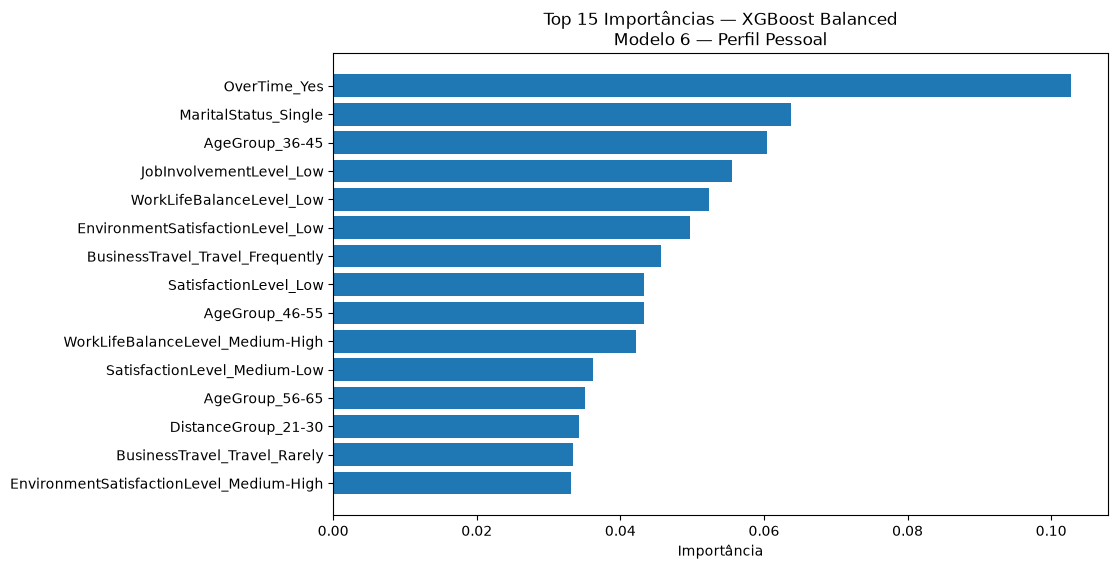

,Feature,Importance
0,OverTime_Yes,0.102798
6,MaritalStatus_Single,0.063834
2,AgeGroup_36-45,0.060444
9,JobInvolvementLevel_Low,0.055549
18,WorkLifeBalanceLevel_Low,0.052325
12,EnvironmentSatisfactionLevel_Low,0.049696
7,BusinessTravel_Travel_Frequently,0.045724
15,SatisfactionLevel_Low,0.043317
3,AgeGroup_46-55,0.043257
19,WorkLifeBalanceLevel_Medium-High,0.042214


In [7]:
for _, row in top_5_best_xgb.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    importance_df = interpretation_results_xgb[variable_set_name][model_name].copy()
    
    top_importance = importance_df.head(15).sort_values(by="Importance", ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_importance["Feature"], top_importance["Importance"])
    plt.xlabel("Importância")
    plt.title(f"Top 15 Importâncias — {model_name}\n{variable_set_name}")
    plt.show()
    
    display(importance_df.head(20))

SHAP — XGBoost | Modelo 2 — Nível Hierárquico e Benefícios
(441, 25)
(441, 25)


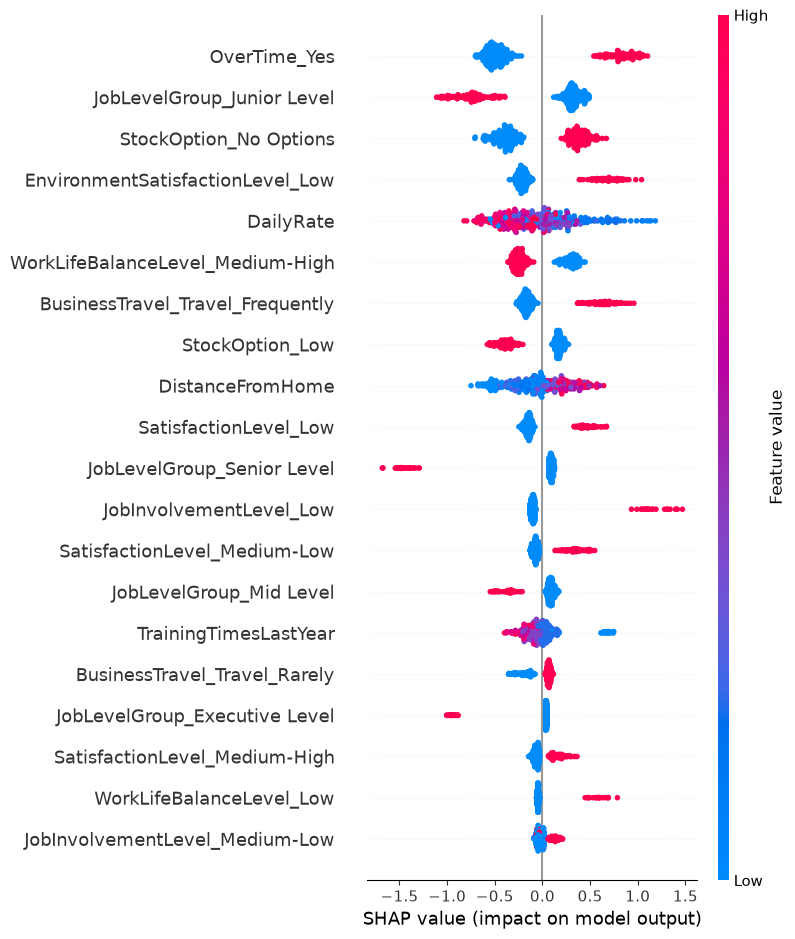

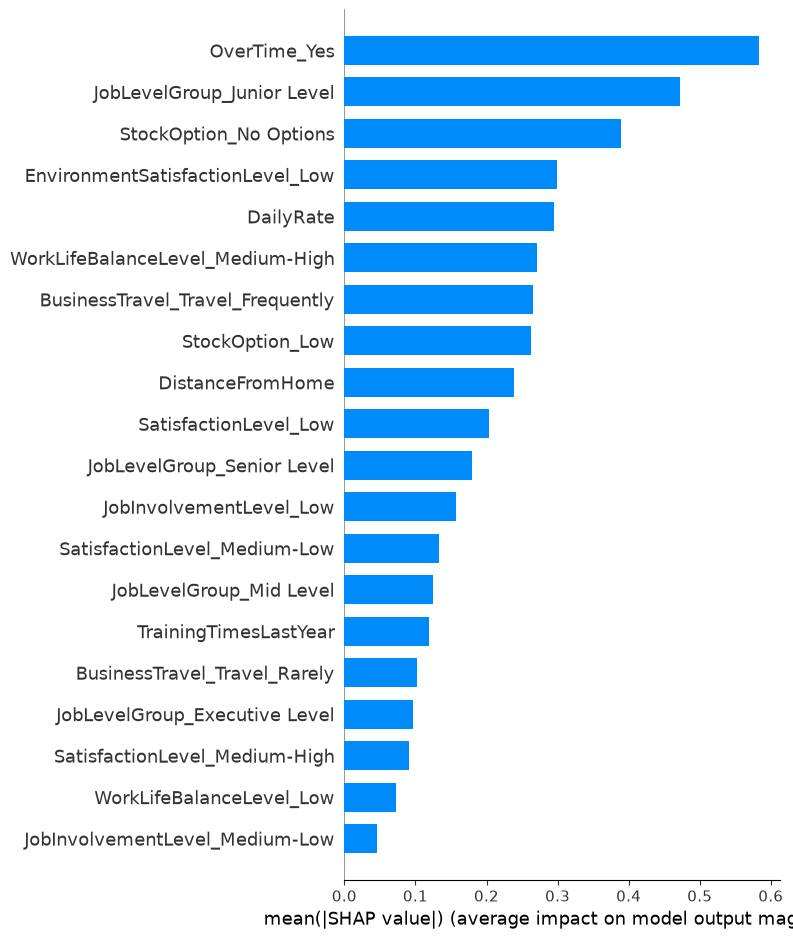

SHAP — XGBoost | Modelo 2 — Nível Hierárquico
(441, 22)
(441, 22)


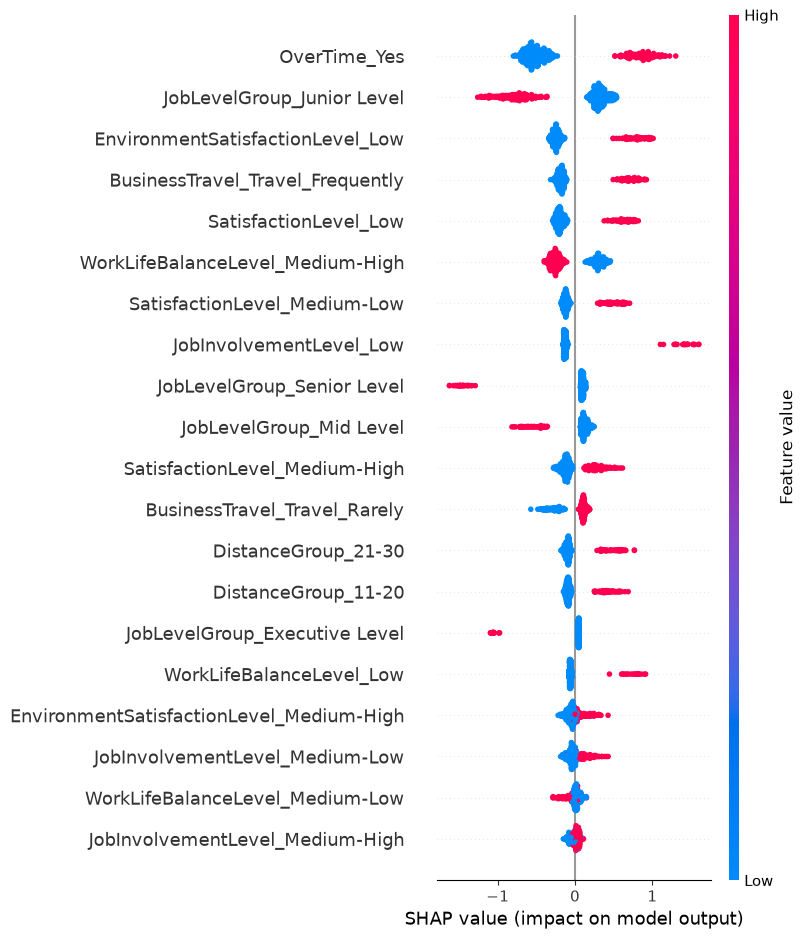

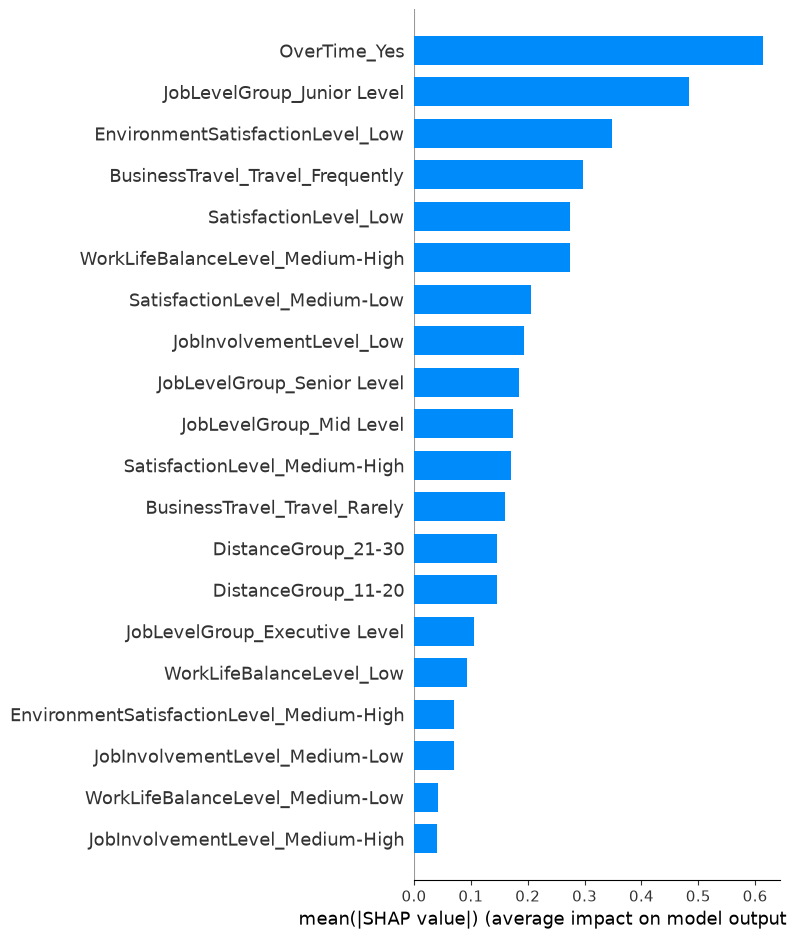

SHAP — XGBoost Balanced | Modelo 2 — Nível Hierárquico e Benefícios
(441, 25)
(441, 25)


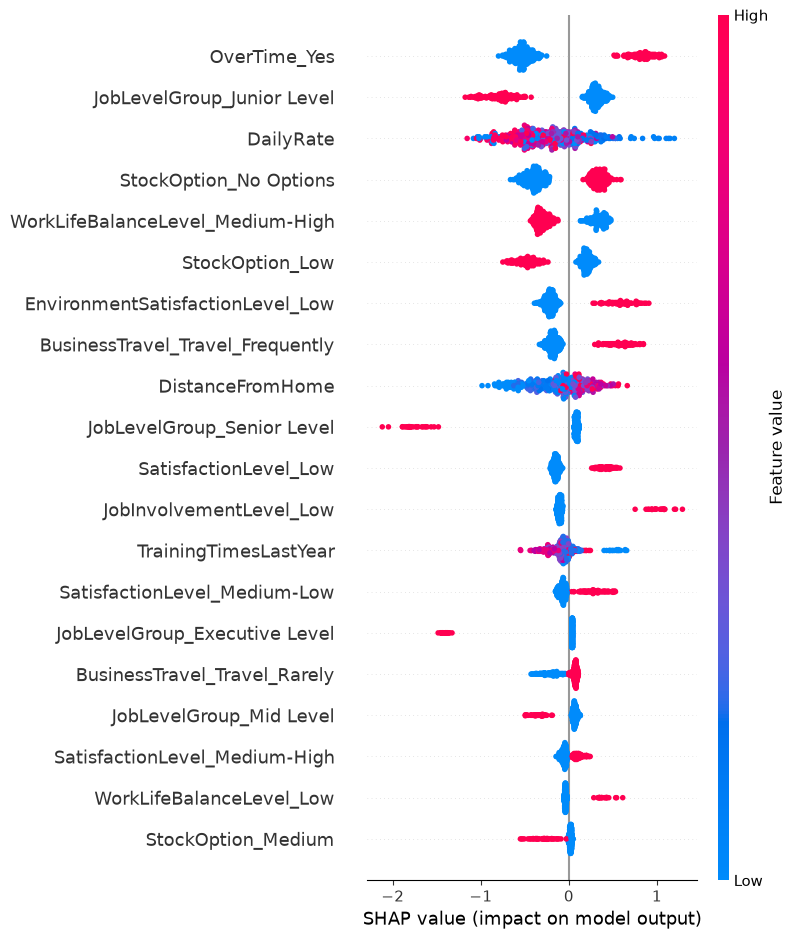

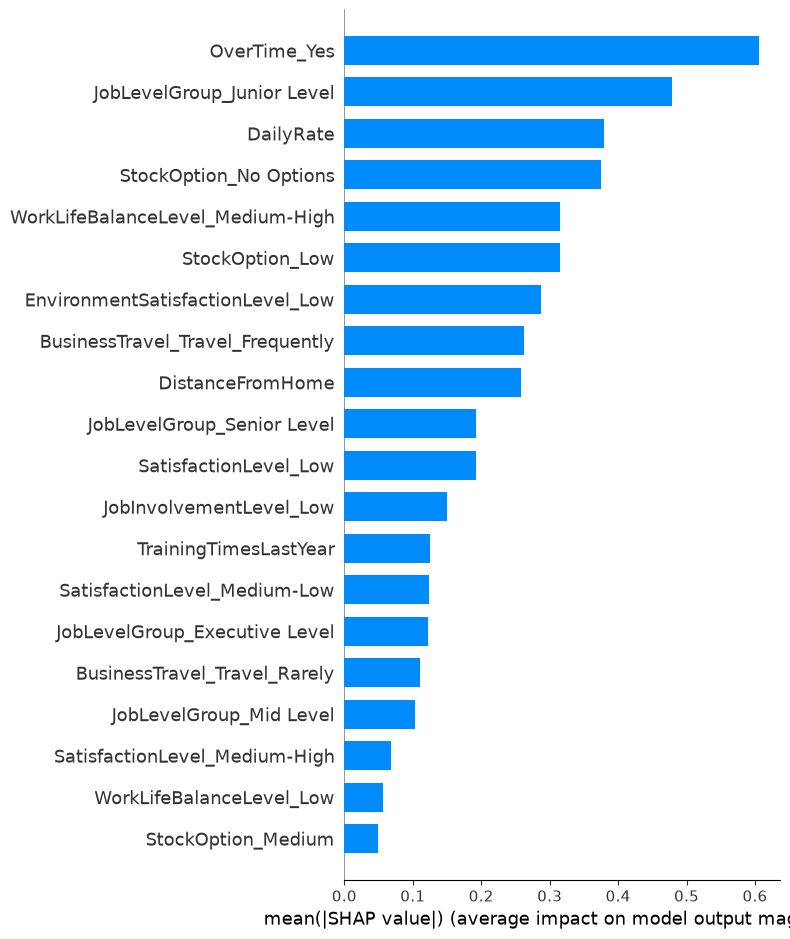

SHAP — XGBoost Balanced | Modelo 2 — Nível Hierárquico
(441, 22)
(441, 22)


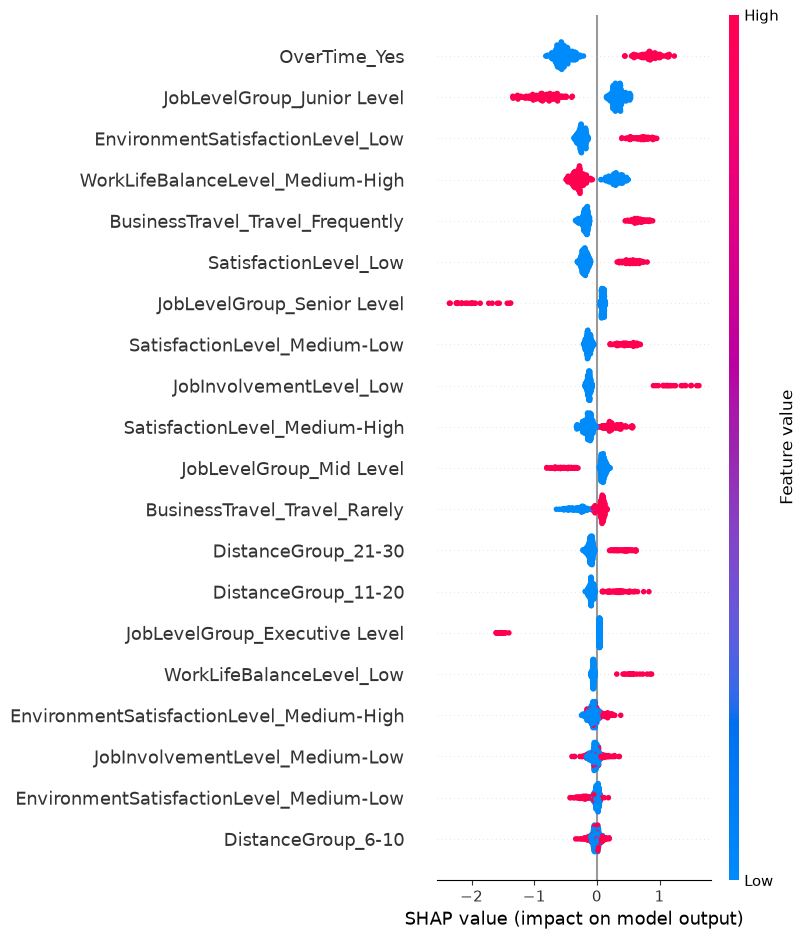

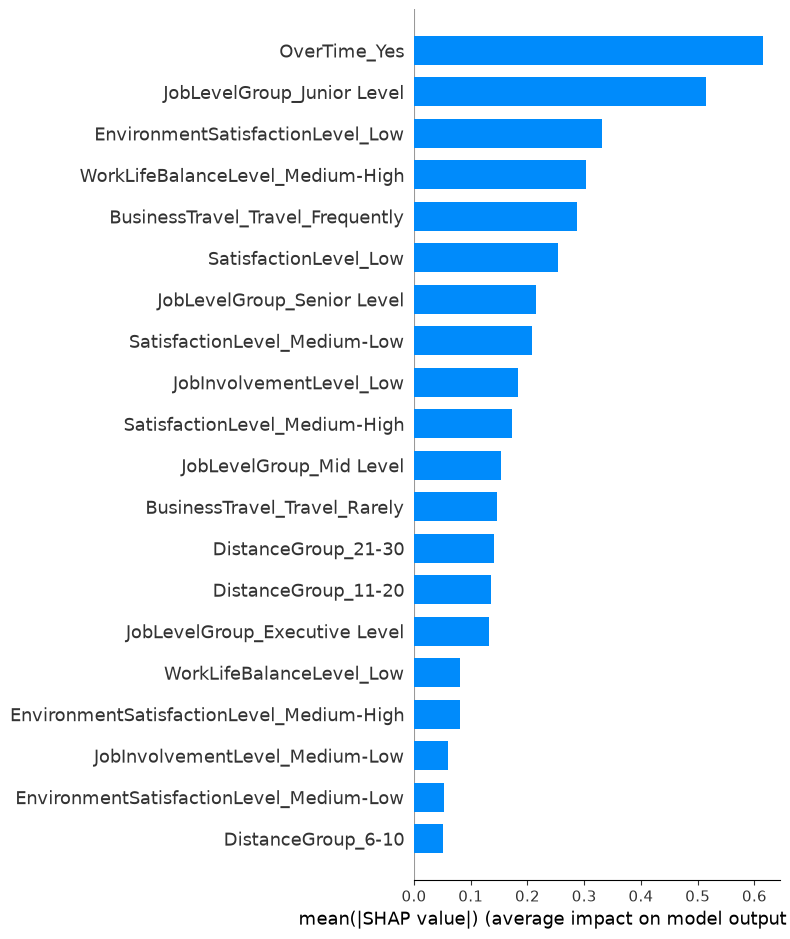

SHAP — XGBoost Balanced | Modelo 6 — Perfil Pessoal
(441, 24)
(441, 24)


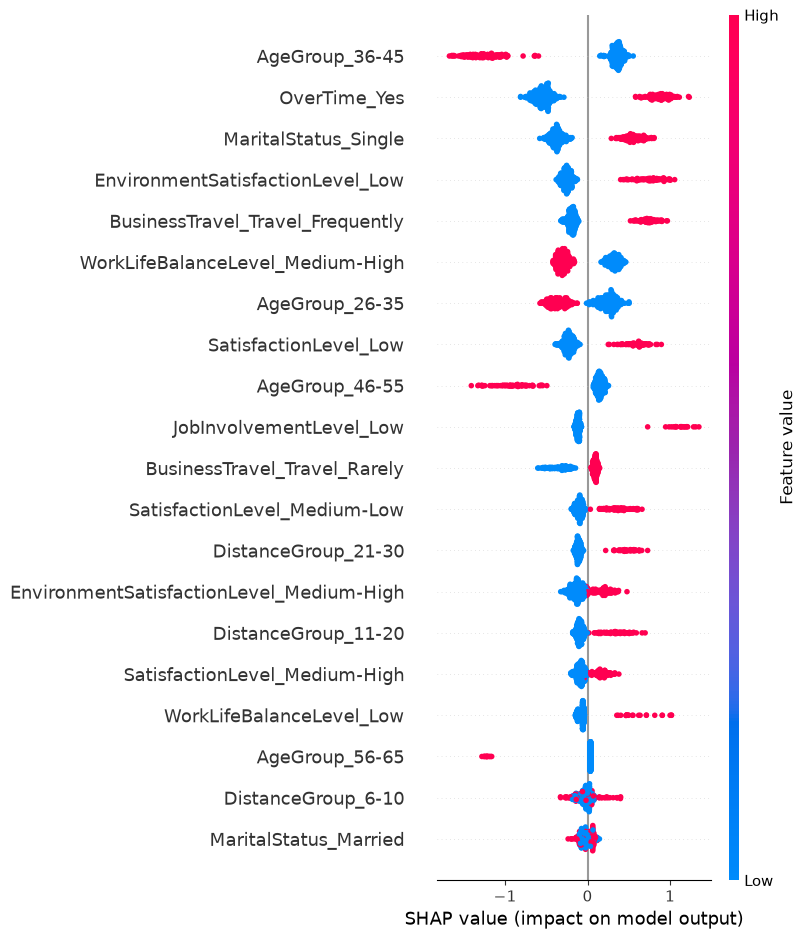

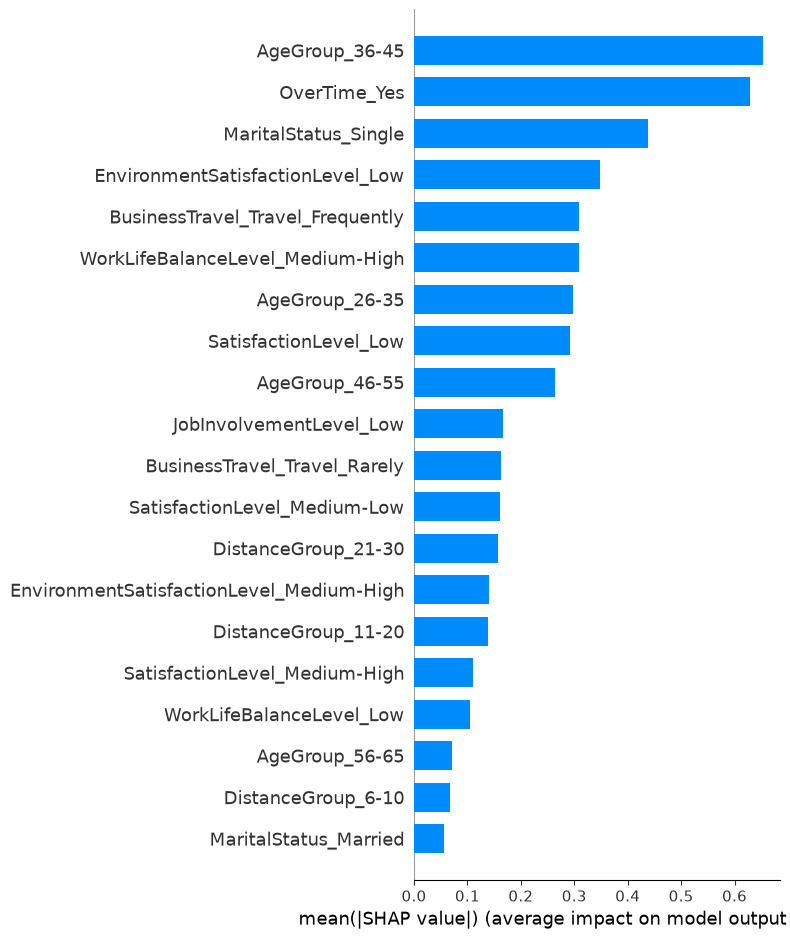

In [8]:
for _, row in top_5_best_xgb.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(xgboost_estimators_dict[model_name]["estimator"])
    balance_method = xgboost_estimators_dict[model_name].get("balance_method", None)
    
    if balance_method == "sample_weight":
        
        sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_train
        )
        
        estimator.fit(X_train, y_train, sample_weight=sample_weight)
        
    else:
        estimator.fit(X_train, y_train)
    
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_test)
    
    if isinstance(shap_values, list):
        shap_values_class1 = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values
    
    print(f"SHAP — {model_name} | {variable_set_name}")
    print(shap_values_class1.shape)
    print(X_test.shape)
    
    shap.summary_plot(shap_values_class1, X_test)
    shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

# Validação Cruzada

In [9]:
cv_xgb = run_cross_validation_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict={
        "XGBoost": estimators_dict["XGBoost"],
        "XGBoost Balanced": estimators_dict["XGBoost Balanced"]
    },
    target="AttritionFlag"
)

cv_xgb.sort_values("F1_Mean", ascending=False)

,Variable_Set,Model,Accuracy_Mean,Accuracy_Std,Precision_Mean,Precision_Std,Recall_Mean,Recall_Std,F1_Mean,F1_Std,AUC_Mean,AUC_Std,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
29,Modelo 8 — Integrado Multidimensional,XGBoost Balanced,0.814,0.028,0.442,0.064,0.603,0.099,0.510,0.076,0.808,0.051,7,11,43
28,Modelo 8 — Integrado Multidimensional,XGBoost,0.876,0.021,0.735,0.141,0.367,0.070,0.486,0.087,0.814,0.053,7,11,43
7,Modelo 4 — Trajetória Organizacional,XGBoost Balanced,0.759,0.045,0.371,0.061,0.662,0.064,0.473,0.059,0.767,0.036,0,8,22
21,Modelo 4 — Experiência Profissional,XGBoost Balanced,0.780,0.032,0.383,0.053,0.582,0.070,0.461,0.058,0.758,0.043,4,6,19
17,Modelo 2 — Nível Hierárquico e Benefícios,XGBoost Balanced,0.777,0.026,0.380,0.041,0.591,0.067,0.461,0.044,0.777,0.038,3,8,25
11,Modelo 6 — Perfil Pessoal,XGBoost Balanced,0.763,0.029,0.363,0.049,0.620,0.081,0.457,0.059,0.760,0.042,0,9,24
15,Modelo 1 — Função Profissional Misto,XGBoost Balanced,0.769,0.032,0.369,0.065,0.603,0.112,0.456,0.076,0.759,0.048,3,7,26
1,Modelo 1 — Função Profissional,XGBoost Balanced,0.750,0.027,0.352,0.033,0.649,0.088,0.455,0.041,0.768,0.039,0,8,26
9,Modelo 5 — Estabilidade e Benefícios,XGBoost Balanced,0.757,0.028,0.355,0.042,0.607,0.088,0.446,0.049,0.775,0.046,0,9,24
5,Modelo 3 — Faixa Salarial,XGBoost Balanced,0.755,0.036,0.353,0.044,0.603,0.071,0.444,0.048,0.750,0.059,0,8,21
